# QFT- Circuit Implementation

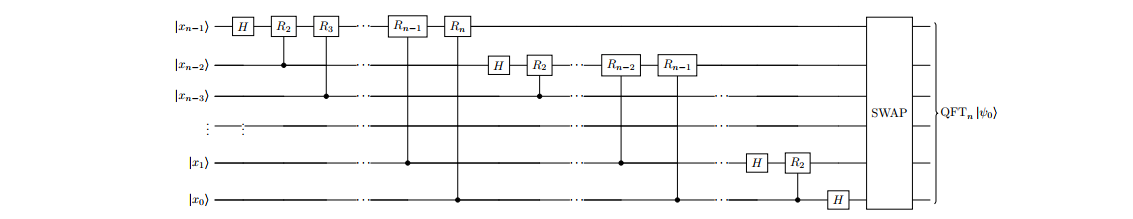

1. MSB: $x_{n-1}$
2. LSB: $x_0$
3. $R_k =
\begin{pmatrix}
1 & 0 \\
0 & \text{exp}({\frac{2\pi i}{2^k}}) \\
\end{pmatrix}$
#### - $R_2 \rightarrow \text{exp}({\frac{2\pi i}{2^2}}) = \text{exp}({\frac{\pi i}{2}}) $
#### - $R_3 \rightarrow \text{exp}({\frac{2\pi i}{2^3}}) = \text{exp}({\frac{\pi i}{4}}) $
#### - $R_4 \rightarrow \text{exp}({\frac{2\pi i}{2^4}}) = \text{exp}({\frac{\pi i}{8}}) $
  

In [1]:
from qiskit import *
from qiskit_aer import *
from qiskit.visualization import *
from qiskit.quantum_info import *

import numpy as np

## Visualizatin function

In [2]:
def qplot(x):
    return x.draw(scale=0.1, fold=-1, cregbundle=True, initial_state=True)

## Implementation QFT

### Two-Qubit

In [15]:
qc = QuantumCircuit(2)

# initialization
qc.x(0)
qc.barrier(label = 'init')

# First step on MSB qubit
qc.h(1)
qc.cp(np.pi/2, 0, 1)

# second step on LSB qubit
qc.h(0)


# Apply SWAP Gate
qc.swap(0,1)




display(qplot(qc), Statevector(qc).draw('latex'))

┌───┐ init               ┌───┐   
q_0: |0>┤ X ├──░─────────■───────┤ H ├─X─
        └───┘  ░   ┌───┐ │P(π/2) └───┘ │ 
q_1: |0>───────░───┤ H ├─■─────────────X─
               ░   └───┘

<IPython.core.display.Latex object>

In [8]:
from qiskit.circuit.library import QFT

In [16]:
circ = QuantumCircuit(2)
circ.x(0)
circ.barrier()
circ.append(QFT(2), [0,1])

display(qplot(circ.decompose(reps = 2)), Statevector(circ).draw('latex'))

┌──────────┐ ░               ┌───┐   
q_0: |0>┤ U(π,0,π) ├─░───────■───────┤ H ├─X─
        └──────────┘ ░ ┌───┐ │P(π/2) └───┘ │ 
q_1: |0>─────────────░─┤ H ├─■─────────────X─
                     ░ └───┘

<IPython.core.display.Latex object>

### Three-qubit

In [34]:
qc = QuantumCircuit(3)


# initialization
qc.x(0)
qc.barrier(label = 'init')

# First step on MSB qubit
qc.h(2)
qc.cp(np.pi/2, 1, 2)
qc.cp(np.pi/4, 0, 2)

# second step on middle qubit
qc.h(1)
qc.cp(np.pi/2, 0, 1)

# third step on LSB qubit
qc.h(0)

# Apply SWAP Gate
qc.swap(0,2)




display(qplot(qc), Statevector(qc).draw('latex'))

┌───┐ init                                      ┌───┐   
q_0: |0>┤ X ├──░──────────────────■─────────────■───────┤ H ├─X─
        └───┘  ░                  │       ┌───┐ │P(π/2) └───┘ │ 
q_1: |0>───────░─────────■────────┼───────┤ H ├─■─────────────┼─
               ░   ┌───┐ │P(π/2)  │P(π/4) └───┘               │ 
q_2: |0>───────░───┤ H ├─■────────■───────────────────────────X─
               ░   └───┘

<IPython.core.display.Latex object>

### Qiskit implementation of QFT

In [33]:
circ = QuantumCircuit(3)
circ.x(0)
circ.barrier(label = 'init')

circ.append(QFT(3), [0,1,2])

display(qplot(circ.decompose(reps = 2)), Statevector(circ).draw('latex'))

┌──────────┐ init                                      ┌───┐   
q_0: |0>┤ U(π,0,π) ├──░───────────────────────■────────■───────┤ H ├─X─
        └──────────┘  ░                 ┌───┐ │        │P(π/2) └───┘ │ 
q_1: |0>──────────────░─────────■───────┤ H ├─┼────────■─────────────┼─
                      ░   ┌───┐ │P(π/2) └───┘ │P(π/4)                │ 
q_2: |0>──────────────░───┤ H ├─■─────────────■──────────────────────X─
                      ░   └───┘

<IPython.core.display.Latex object>